# RoBERTa Sentiment Analysis

## Objective

The objective of this notebook is to perform transformer-based sentiment analysis on demonetization-related tweets using the RoBERTa model.

RoBERTa is a transformer-based NLP model capable of understanding contextual relationships between words and generating highly accurate sentiment predictions.

The model classifies tweets into:
- Positive
- Negative
- Neutral

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Transformers
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification

# PyTorch
import torch

# Softmax
from scipy.special import softmax

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Plot Style
plt.style.use('ggplot')

print("Libraries Imported Successfully 🚀")

Libraries Imported Successfully 🚀


In [2]:
# Load Dataset
df = pd.read_csv("C:/Users/rahul/Desktop/demonetization-tweets.csv - Copy/demonetization-tweets.csv")

print("Dataset Loaded Successfully ✅")
print("Dataset Shape:", df.shape)

Dataset Loaded Successfully ✅
Dataset Shape: (14940, 14)


## Load RoBERTa Model and Tokenizer

The pretrained RoBERTa sentiment analysis model and tokenizer are loaded using the Hugging Face Transformers library.

In [3]:
# Pretrained Model Name

MODEL = "cardiffnlp/twitter-roberta-base-sentiment"

In [4]:
# Load Tokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL)

print("Tokenizer Loaded Successfully ✅")

Tokenizer Loaded Successfully ✅


In [5]:
# Load Model

model = AutoModelForSequenceClassification.from_pretrained(MODEL)

print("RoBERTa Model Loaded Successfully ✅")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RoBERTa Model Loaded Successfully ✅


## Test RoBERTa on Sample Tweet

This section demonstrates transformer-based sentiment prediction for a sample tweet.

In [6]:
# Sample Tweet

sample_tweet = df['cleaned_text'][0]

print("Sample Tweet:")
print(sample_tweet)

Sample Tweet:
critical question paytm informed demonetization edict pm clearly fishy requires full disclosure amp


In [7]:
# Encode Text

encoded_text = tokenizer(
    sample_tweet,
    return_tensors='pt'
)

encoded_text

{'input_ids': tensor([[    0, 25398,   864,   582, 26989,  3978, 12959,   594,  1938,  4803,
         11726,  4751,  2563,  3539,   219,  3441,   455,  6262, 28127,     2]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}

## Generate RoBERTa Prediction

The encoded tweet is passed through the transformer model to generate sentiment scores.

In [8]:
# Model Prediction

output = model(**encoded_text)

output

SequenceClassifierOutput(loss=None, logits=tensor([[ 0.9360,  1.1897, -2.3000]], grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)

## Apply Softmax Function

Softmax converts raw model outputs into probability distributions for:
- positive
- negative
- neutral sentiments

In [9]:
# Extract Scores

scores = output[0][0].detach().numpy()

scores

array([ 0.93598694,  1.1897172 , -2.299978  ], dtype=float32)

In [10]:
# Create Sentiment Score Dictionary

scores_dict = {
    'roberta_neg': scores[0],
    'roberta_neu': scores[1],
    'roberta_pos': scores[2]
}

scores_dict

{'roberta_neg': np.float32(0.93598694),
 'roberta_neu': np.float32(1.1897172),
 'roberta_pos': np.float32(-2.299978)}

## Create RoBERTa Prediction Function

This function automates sentiment prediction for tweet text using the RoBERTa transformer model.

In [11]:
# RoBERTa Prediction Function

def polarity_scores_roberta(text):
    
    # Encode Text
    encoded_text = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        max_length=512
    )
    
    # Model Prediction
    output = model(**encoded_text)
    
    # Extract Scores
    scores = output[0][0].detach().numpy()
    
    # Softmax
    scores = softmax(scores)
    
    # Create Dictionary
    scores_dict = {
        'roberta_neg': scores[0],
        'roberta_neu': scores[1],
        'roberta_pos': scores[2]
    }
    
    return scores_dict

## Generate RoBERTa Predictions using Batch Processing

Batch inference improves efficiency by processing multiple tweets simultaneously while preserving prediction quality.

In [15]:
# Batch Prediction Function

def predict_batch(texts):

    encoded = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors='pt'
    )

    with torch.no_grad():

        outputs = model(**encoded)

    scores = outputs.logits.detach().numpy()

    scores = softmax(
        scores,
        axis=1
    )

    return scores

## Generate Sentiment Predictions

RoBERTa sentiment predictions are generated for all tweets in the dataset.

In [16]:
# Generate Predictions

# Batch Processing


batch_size = 64

all_scores = []

for start in range(0, len(df), batch_size):

    batch = (
        df['cleaned_text']
        .iloc[start:start+batch_size]
        .astype(str)
        .tolist()
    )

    scores = predict_batch(batch)

    all_scores.extend(scores)

print("Batch Prediction Completed ✅")

Batch Prediction Completed ✅


In [17]:
# Convert Results

scores_df = pd.DataFrame(
    all_scores,
    columns=[
        'roberta_neg',
        'roberta_neu',
        'roberta_pos'
    ]
)

scores_df.head()

,roberta_neg,roberta_neu,roberta_pos
0,0.429526,0.553584,0.016890
1,0.325697,0.646863,0.027441
2,0.177474,0.798007,0.024519
3,0.058020,0.890410,0.051570
4,0.281957,0.670873,0.047169


In [18]:
# Merge Results

df = pd.concat(
    [df, scores_df],
    axis=1
)

print("Results Merged ✅")

Results Merged ✅


## Classify Sentiments

Tweets are classified into:
- Positive
- Negative
- Neutral

based on highest RoBERTa probability score.

In [19]:
# Sentiment Classification Function

def classify_roberta_sentiment(row):
    
    if row['roberta_pos'] > row['roberta_neg'] and row['roberta_pos'] > row['roberta_neu']:
        return 'Positive'
    
    elif row['roberta_neg'] > row['roberta_pos'] and row['roberta_neg'] > row['roberta_neu']:
        return 'Negative'
    
    else:
        return 'Neutral'

In [20]:
# Apply Classification

df['roberta_sentiment'] = df.apply(
    classify_roberta_sentiment,
    axis=1
)

print("RoBERTa Sentiment Classification Completed ✅")

RoBERTa Sentiment Classification Completed ✅


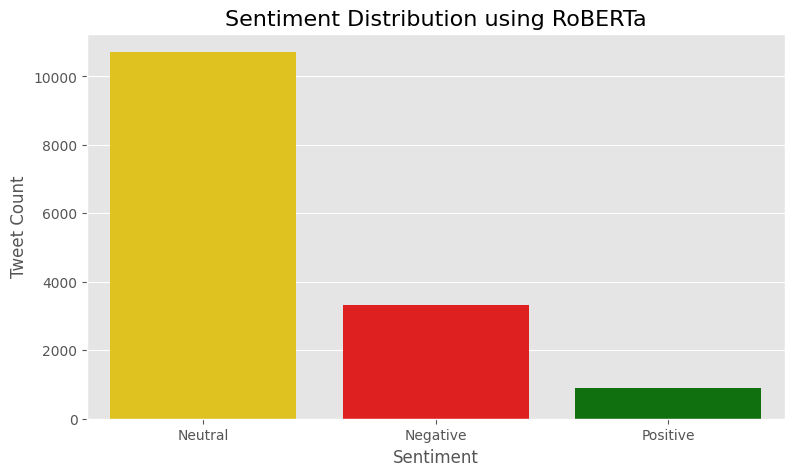

In [22]:
# Plot Sentiment Distribution

plt.figure(figsize=(9,5))

sns.countplot(
    x='roberta_sentiment',
    data=df,
    palette={
        'Negative':'red',
        'Neutral':'gold',
        'Positive':'green'
    }
)

plt.title(
    "Sentiment Distribution using RoBERTa",
    fontsize=16
)

plt.xlabel("Sentiment")
plt.ylabel("Tweet Count")

plt.show()